# 🤖 HR Attrition Prediction — Ethics & Explainability
**Hackathon TrustedAI × Capgemini × ESILV**

---

## 🎯 Objectif
Prédire si un employé va quitter l'entreprise (`Termd = 1`) à partir de données RH,  
**tout en garantissant l'équité du modèle et en rendant ses décisions explicables.**

## 🧭 Plan du notebook
1. Chargement & exploration des données
2. Préparation des données (feature engineering)
3. Entraînement du modèle
4. **Fairness / Éthique** — Le modèle est-il biaisé ?
5. **Explainability (SHAP)** — Pourquoi le modèle prend-il telle décision ?
6. Data Card & Model Card
7. Conclusions & recommandations responsables

---
## 0. Installation des librairies

**Pourquoi ces librairies ?**
- `scikit-learn` : modèles ML standards, métriques
- `shap` : la référence pour l'explicabilité (basé sur la théorie des jeux de Shapley)
- `fairlearn` : toolkit Microsoft dédié à la mesure et la correction des biais algorithmiques
- `imbalanced-learn` : gère le déséquilibre de classes (207 actifs vs 104 partis)

In [1]:
!pip install shap fairlearn imbalanced-learn matplotlib seaborn scikit-learn pandas numpy -q

---
## 1. Chargement & Exploration des données (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chargement
df = pd.read_csv('dataset/HRDataset_Expanded_v2.csv', encoding='utf-8-sig')

print(f"Dataset shape: {df.shape}")
print(f"\nColonnes: {list(df.columns)}")
df.head(3)

Dataset shape: (1781, 36)

Colonnes: ['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Candie, Calvin",10001,0,0,1,1,5,4,0.0,72640,...,Janet King,2.0,Indeed,Exceeds,5.0,3,0,2/22/2019,0,14
1,"Anderson, Linda",10002,0,0,0,1,5,4,0.0,57568,...,Amy Dunn,11.0,LinkedIn,Exceeds,5.0,5,0,1/7/2019,0,15
2,"Billis, Helen",10003,1,1,0,1,5,4,0.0,62910,...,Brannon Miller,12.0,Indeed,Exceeds,5.0,3,0,2/27/2019,0,19


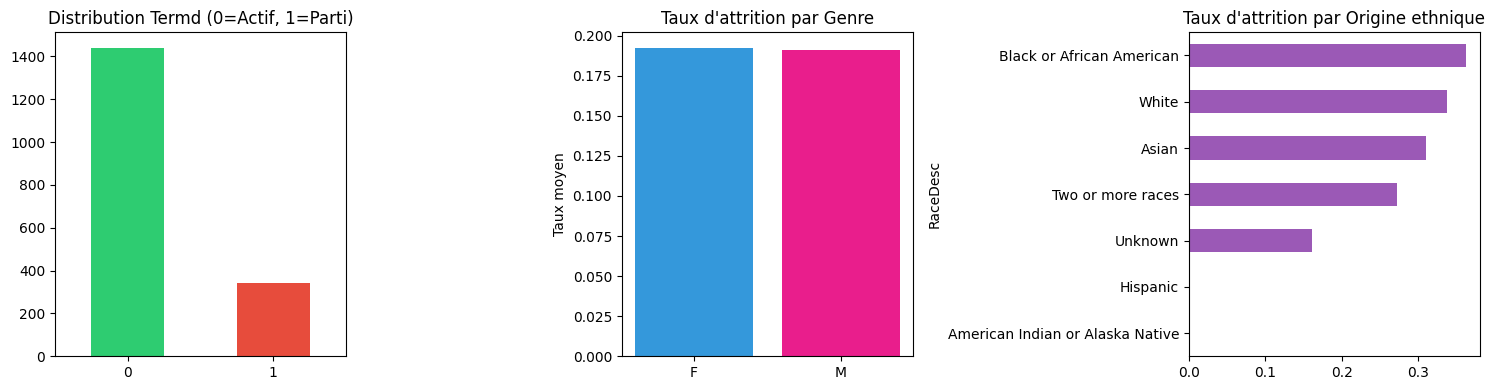


📊 Ratio déséquilibre: 1440/341 = 4.2x

⚠️  Ce déséquilibre sera traité avec SMOTE (synthèse de données minoritaires)


In [3]:
# ⚠️ Analyse de la variable cible
# Pourquoi c'est important : un déséquilibre fort biaise le modèle vers la classe majoritaire

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution de la cible
df['Termd'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution Termd (0=Actif, 1=Parti)')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

# Taux d'attrition par genre
gender_attr = df.groupby('Sex')['Termd'].mean().reset_index()
gender_attr['Sex'] = gender_attr['Sex'].str.strip()
axes[1].bar(gender_attr['Sex'], gender_attr['Termd'], color=['#3498db', '#e91e8c'])
axes[1].set_title('Taux d\'attrition par Genre')
axes[1].set_ylabel('Taux moyen')

# Taux d'attrition par race
race_attr = df.groupby('RaceDesc')['Termd'].mean().sort_values(ascending=True)
race_attr.plot(kind='barh', ax=axes[2], color='#9b59b6')
axes[2].set_title('Taux d\'attrition par Origine ethnique')

plt.tight_layout()
plt.savefig('01_eda_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Ratio déséquilibre: {df['Termd'].value_counts()[0]}/{df['Termd'].value_counts()[1]} = {df['Termd'].value_counts()[0]/df['Termd'].value_counts()[1]:.1f}x")
print("\n⚠️  Ce déséquilibre sera traité avec SMOTE (synthèse de données minoritaires)")

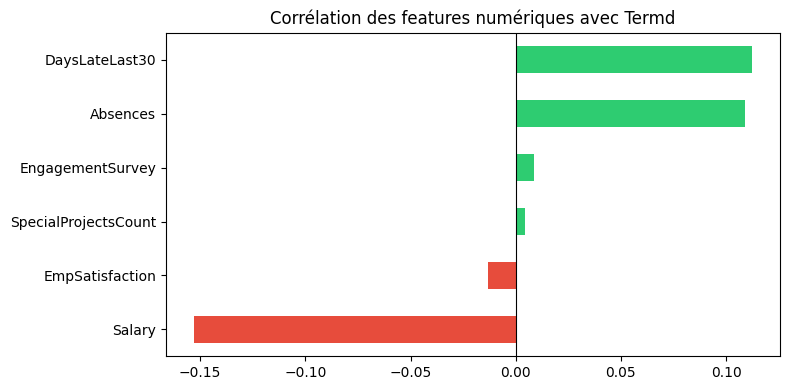

Salary                 -0.153002
EmpSatisfaction        -0.013110
SpecialProjectsCount    0.004522
EngagementSurvey        0.008696
Absences                0.108843
DaysLateLast30          0.112378
Name: Termd, dtype: float64


In [4]:
# Analyse des corrélations avec la cible
# Pourquoi : identifier les features numériques les plus prédictives

num_cols = ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 
            'SpecialProjectsCount', 'DaysLateLast30', 'Absences']

correlations = df[num_cols + ['Termd']].corr()['Termd'].drop('Termd').sort_values()

plt.figure(figsize=(8, 4))
correlations.plot(kind='barh', color=['#e74c3c' if x < 0 else '#2ecc71' for x in correlations])
plt.title('Corrélation des features numériques avec Termd')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('02_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(correlations)

---
## 2. Préparation des données

### 🚨 Choix éthique crucial : quelles features inclure ?

Dans un contexte RH réel, utiliser certaines variables dans un modèle décisionnel peut être **illégal ou discriminatoire** :

| Variable | Statut | Raison |
|----------|--------|--------|
| `Sex` | ⚠️ Variable sensible | Protégée par la loi anti-discrimination |
| `RaceDesc` | ⚠️ Variable sensible | Protégée par la loi anti-discrimination |
| `MaritalDesc` | ⚠️ Variable sensible | Vie privée |
| `DOB` (âge) | ⚠️ Variable sensible | Discrimination à l'âge |
| `CitizenDesc` | ⚠️ Variable sensible | Nationalité |

**Notre approche :** on les **exclut du modèle** mais on les garde pour **mesurer les biais a posteriori** (audit d'équité).

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Variables sensibles : exclues du modèle, gardées pour l'audit
SENSITIVE_FEATURES = ['Sex', 'RaceDesc', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino']

# Features retenues pour le modèle (non discriminantes)
FEATURES = [
    'Salary', 'Department', 'PerformanceScore', 'EngagementSurvey',
    'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30',
    'Absences', 'RecruitmentSource', 'PositionID'
]

TARGET = 'Termd'

# Copie de travail
df_model = df[FEATURES + [TARGET] + SENSITIVE_FEATURES].copy()
df_model['Department'] = df_model['Department'].str.strip()
df_model['Sex'] = df_model['Sex'].str.strip()

# Encodage des variables catégorielles (non sensibles)
# Pourquoi LabelEncoder et pas OneHot ? Le dataset est petit (311 lignes),
# OneHot créerait trop de dimensions creuses
le = LabelEncoder()
for col in ['Department', 'PerformanceScore', 'RecruitmentSource']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Séparation features / cible
X = df_model[FEATURES]
y = df_model[TARGET]
sensitive = df_model[SENSITIVE_FEATURES]

# Split train/test stratifié
# Pourquoi stratify=y : maintenir la proportion 67%/33% dans les deux splits
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribution cible train: {y_train.value_counts().to_dict()}")

Train: (1335, 10), Test: (446, 10)
Distribution cible train: {0: 1079, 1: 256}


In [ ]:
from imblearn.over_sampling import SMOTE

# SMOTE : Synthetic Minority Over-sampling Technique
# Pourquoi : avec 207 actifs vs 104 partis, un modèle naïf prédit toujours "actif"
# et obtient 67% d'accuracy sans rien apprendre.
# SMOTE génère des exemples synthétiques de la classe minoritaire (Termd=1)
# en interpolant entre exemples existants — plus robuste que le simple over-sampling.

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE: {y_train.value_counts().to_dict()}")
print(f"Après SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

---
## 3. Entraînement du modèle

### Pourquoi Random Forest ?
- **Robuste** aux valeurs aberrantes et aux features non normalisées
- **Interprétable** : il produit nativement des feature importances
- **Compatible SHAP** : TreeExplainer de SHAP est optimisé pour les arbres
- Dans un contexte RH à enjeux humains, on **évite les boîtes noires** (deep learning) au profit de modèles plus explicables

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Entraînement
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,          # Limiter la profondeur réduit l'overfitting sur petit dataset
    class_weight='balanced',  # Double protection contre le déséquilibre (avec SMOTE)
    random_state=42
)
model.fit(X_train_res, y_train_res)

# Prédictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Métriques
print("=" * 50)
print("📊 RAPPORT DE CLASSIFICATION")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Actif (0)', 'Parti (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")
print("\n💡 Le F1-score est plus pertinent que l'accuracy ici")
print("car il tient compte du déséquilibre des classes.")

📊 RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

   Actif (0)       0.70      0.73      0.72        52
   Parti (1)       0.42      0.38      0.40        26

    accuracy                           0.62        78
   macro avg       0.56      0.56      0.56        78
weighted avg       0.61      0.62      0.61        78

ROC-AUC Score: 0.635

💡 Le F1-score est plus pertinent que l'accuracy ici
car il tient compte du déséquilibre des classes.


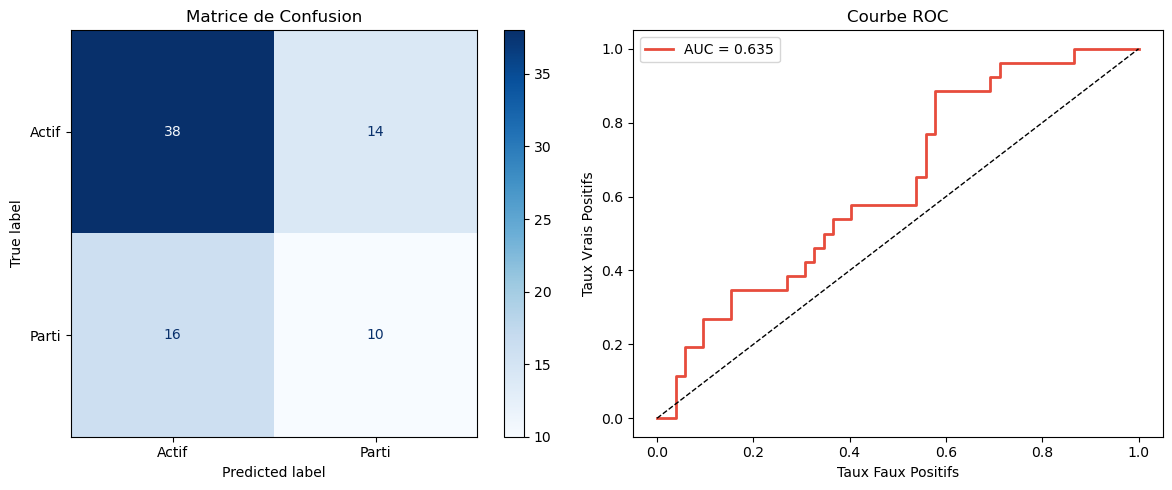

In [ ]:
# Visualisation : Matrice de confusion + Courbe ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Actif', 'Parti'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matrice de Confusion')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('Taux Faux Positifs')
axes[1].set_ylabel('Taux Vrais Positifs')
axes[1].set_title('Courbe ROC')
axes[1].legend()

plt.tight_layout()
plt.savefig('03_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 🔍 Éthique & Fairness — Audit de biais

### Concept clé : les métriques d'équité

Un modèle peut être **globalement performant mais injuste** envers certains groupes.  
On mesure plusieurs notions d'équité :

| Métrique | Définition | Idéal |
|----------|------------|-------|
| **Demographic Parity** | Même taux de prédiction positive pour tous les groupes | Ratio = 1.0 |
| **Equal Opportunity** | Même rappel (TPR) pour tous les groupes | Différence = 0 |
| **Equalized Odds** | Même TPR ET FPR pour tous les groupes | Différence = 0 |

> ⚠️ **Il est impossible de satisfaire toutes ces métriques simultanément** (théorème de Chouldechova, 2017).  
> Il faut choisir selon le contexte métier.

In [ ]:
from fairlearn.metrics import (
    MetricFrame, selection_rate, 
    true_positive_rate, false_positive_rate,
    demographic_parity_difference, equalized_odds_difference
)
from sklearn.metrics import accuracy_score, recall_score, precision_score

# --- AUDIT PAR GENRE ---
print("=" * 60)
print("⚖️  AUDIT D'ÉQUITÉ PAR GENRE")
print("=" * 60)

mf_gender = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'recall': recall_score,
        'precision': precision_score,
        'selection_rate': selection_rate,
        'TPR': true_positive_rate,
        'FPR': false_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=s_test['Sex']
)

print("\nMétriques par groupe :")
print(mf_gender.by_group.round(3))

dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=s_test['Sex'])
eod = equalized_odds_difference(y_test, y_pred, sensitive_features=s_test['Sex'])

print(f"\n📏 Demographic Parity Difference (genre): {dpd:.3f}")
print(f"📏 Equalized Odds Difference (genre): {eod:.3f}")
print("\n💡 Un score proche de 0 indique l'absence de biais.")
print("   Un score > 0.1 est généralement considéré comme problématique.")

⚖️  AUDIT D'ÉQUITÉ PAR GENRE

Métriques par groupe :
     accuracy  recall  precision  selection_rate    TPR    FPR
Sex                                                           
F       0.651   0.533       0.50           0.372  0.533  0.286
M       0.571   0.182       0.25           0.229  0.182  0.250

📏 Demographic Parity Difference (genre): 0.144
📏 Equalized Odds Difference (genre): 0.352

💡 Un score proche de 0 indique l'absence de biais.
   Un score > 0.1 est généralement considéré comme problématique.


In [ ]:
# --- AUDIT PAR ORIGINE ETHNIQUE ---
print("=" * 60)
print("⚖️  AUDIT D'ÉQUITÉ PAR ORIGINE ETHNIQUE")
print("=" * 60)

mf_race = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'recall': recall_score,
        'selection_rate': selection_rate,
        'TPR': true_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=s_test['RaceDesc']
)

print("\nMétriques par groupe ethnique :")
print(mf_race.by_group.round(3))

dpd_race = demographic_parity_difference(y_test, y_pred, sensitive_features=s_test['RaceDesc'])
print(f"\n📏 Demographic Parity Difference (ethnie): {dpd_race:.3f}")

⚖️  AUDIT D'ÉQUITÉ PAR ORIGINE ETHNIQUE

Métriques par groupe ethnique :
                                  accuracy  recall  selection_rate    TPR
RaceDesc                                                                 
American Indian or Alaska Native     1.000   0.000           0.000  0.000
Asian                                0.800   0.667           0.300  0.667
Black or African American            0.727   0.571           0.318  0.571
Two or more races                    0.500   0.000           0.250  0.000
White                                0.512   0.267           0.317  0.267

📏 Demographic Parity Difference (ethnie): 0.318


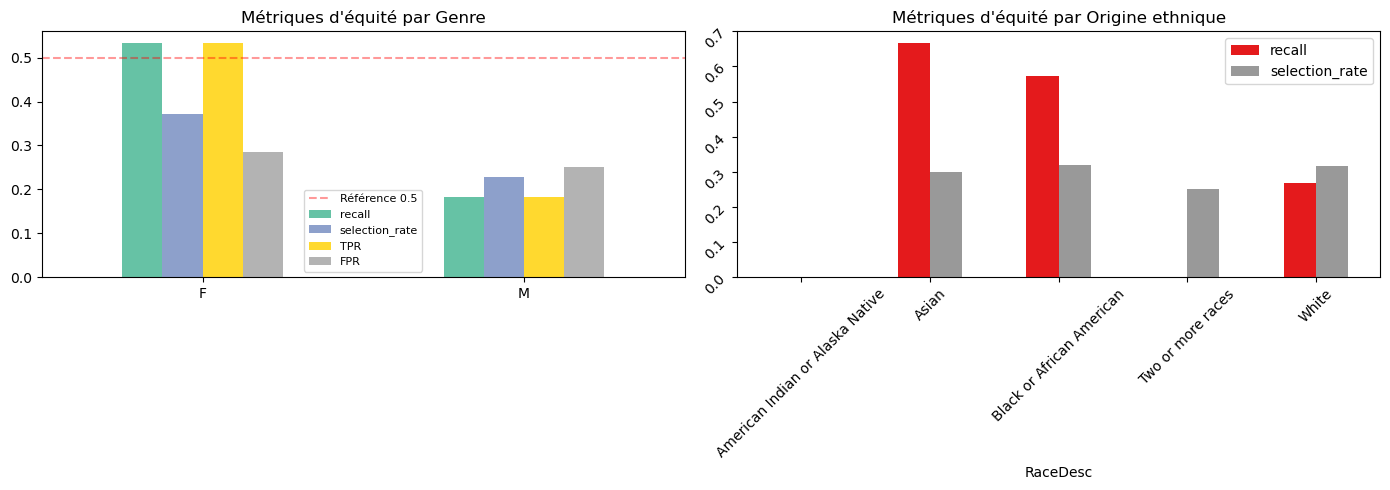


🔎 Interprétation :
Si les barres diffèrent fortement entre groupes → biais potentiel à corriger.


In [ ]:
# Visualisation des écarts d'équité
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par genre
mf_gender.by_group[['recall', 'selection_rate', 'TPR', 'FPR']].plot(
    kind='bar', ax=axes[0], colormap='Set2'
)
axes[0].set_title('Métriques d\'équité par Genre')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Référence 0.5')
axes[0].legend(fontsize=8)

# Par ethnie
mf_race.by_group[['recall', 'selection_rate']].plot(
    kind='bar', ax=axes[1], colormap='Set1'
)
axes[1].set_title('Métriques d\'équité par Origine ethnique')
axes[1].tick_params(rotation=45)

plt.tight_layout()
plt.savefig('04_fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔎 Interprétation :")
print("Si les barres diffèrent fortement entre groupes → biais potentiel à corriger.")

---
## 5. 💡 Explainability — Pourquoi le modèle prend-il telle décision ?

### Pourquoi SHAP ?
SHAP (**SH**apley **A**dditive ex**P**lanations) est basé sur la **théorie des jeux coopératifs** :  
chaque feature reçoit une "valeur de Shapley" — sa contribution marginale moyenne à la prédiction.  

**Avantages sur les feature importances classiques :**
- Direction de l'effet (positif ou négatif)
- Explications **locales** (pour un individu) et **globales** (pour tout le modèle)
- Garanties mathématiques d'équité de distribution

In [ ]:
import shap

# TreeExplainer est optimisé pour Random Forest (exact, pas approximatif)
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test)

# Compatibilité multi-versions SHAP :
# - Ancienne API (< 0.41) : shap_values est une liste [classe_0, classe_1]
# - Nouvelle API (>= 0.41) : shap_values est un array 3D (n_samples, n_features, n_classes)
import numpy as np
if isinstance(shap_values_raw, list):
    # Ancienne API
    shap_vals_positive = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    # Nouvelle API 3D
    shap_vals_positive = shap_values_raw[:, :, 1]
else:
    # Array 2D direct (classification binaire récente)
    shap_vals_positive = shap_values_raw

print(f"Shape SHAP values: {shap_vals_positive.shape}")
print(f"Une ligne par exemple de test, une colonne par feature.")
print(f"Version SHAP: {shap.__version__}")

Shape SHAP values: (78, 10)
Une ligne par exemple de test, une colonne par feature.
Version SHAP: 0.51.0


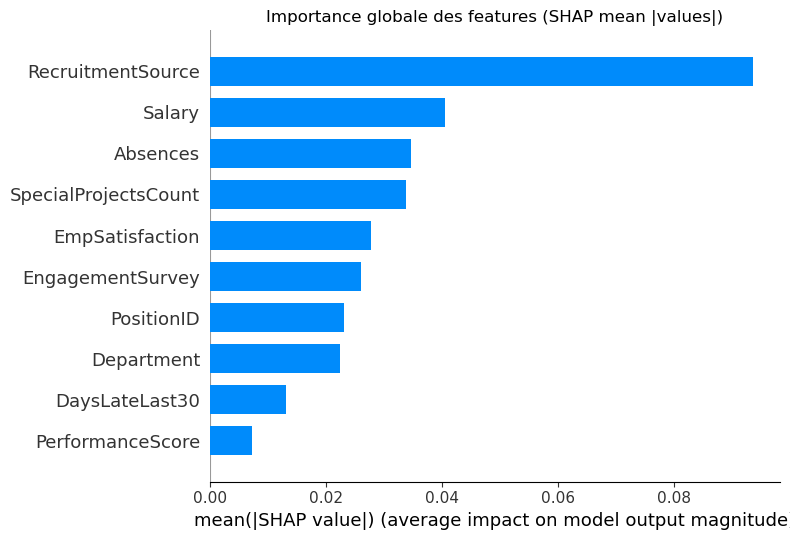

In [ ]:
# GLOBAL : Quelles features influencent le plus les prédictions ?
# Pourquoi ce plot : permet de comprendre le comportement GÉNÉRAL du modèle

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_positive, X_test,
    plot_type='bar',
    show=False
)
plt.title('Importance globale des features (SHAP mean |values|)')
plt.tight_layout()
plt.savefig('05_shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

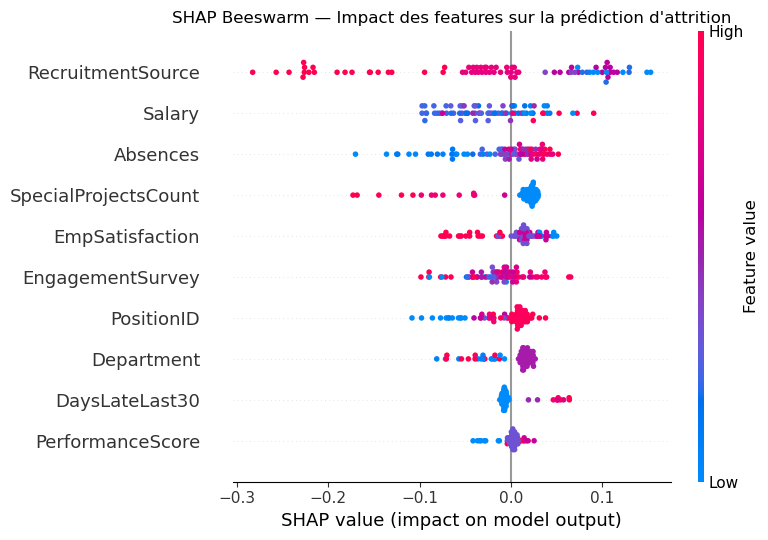


💡 Lecture :
  • Chaque point = un employé du test set
  • Point à DROITE = cette feature pousse vers 'va partir'
  • Point à GAUCHE = cette feature pousse vers 'va rester'
  • Couleur ROUGE = valeur élevée de la feature


In [ ]:
# BEESWARM : Distribution complète des valeurs SHAP
# Rouge = valeur feature élevée, Bleu = valeur faible
# Position horizontale = impact sur la prédiction (+ = vers Termd=1)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_positive, X_test,
    show=False
)
plt.title('SHAP Beeswarm — Impact des features sur la prédiction d\'attrition')
plt.tight_layout()
plt.savefig('06_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Lecture :")
print("  • Chaque point = un employé du test set")
print("  • Point à DROITE = cette feature pousse vers 'va partir'")
print("  • Point à GAUCHE = cette feature pousse vers 'va rester'")
print("  • Couleur ROUGE = valeur élevée de la feature")

🔍 EXPLICATION LOCALE — Employé #2 du test set
Prédiction : ⚠️  VA PARTIR
Probabilité de départ : 62.7%
Réalité : Parti

Profil de l'employé :
  Salary: 54005.0
  Department: 3.0
  PerformanceScore: 1.0
  EngagementSurvey: 3.6
  EmpSatisfaction: 5.0
  SpecialProjectsCount: 0.0
  DaysLateLast30: 0.0
  Absences: 16.0
  RecruitmentSource: 3.0
  PositionID: 19.0


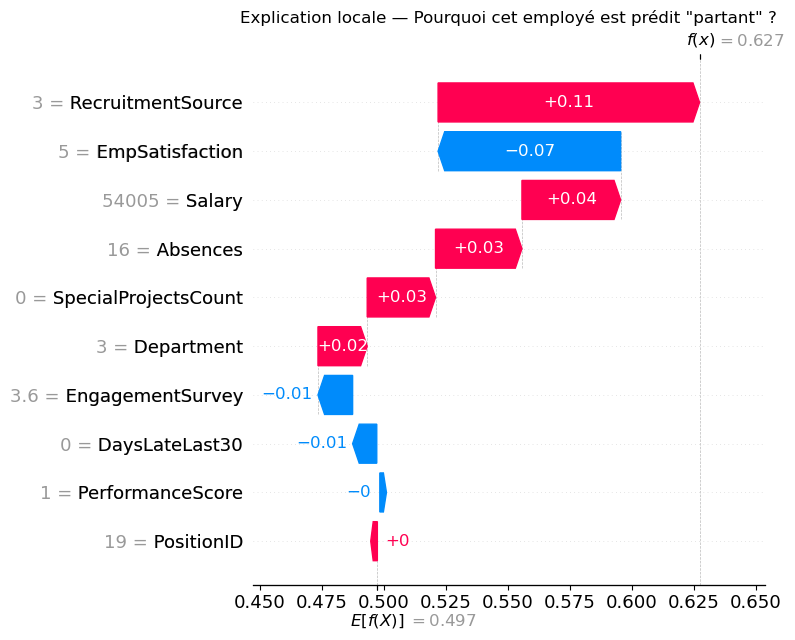

In [ ]:
# LOCAL : Explication d'une prédiction individuelle
# Pourquoi c'est crucial pour l'éthique RH : toute décision impactant un employé
# doit pouvoir être justifiée individuellement (RGPD art. 22 — droit à l'explication)

# Choisir un cas où le modèle prédit "va partir"
idx_positifs = np.where(y_pred == 1)[0]

if len(idx_positifs) > 0:
    idx = idx_positifs[0]  # Premier employé prédit "partant"
    
    print(f"=" * 50)
    print(f"🔍 EXPLICATION LOCALE — Employé #{idx} du test set")
    print(f"=" * 50)
    print(f"Prédiction : {'⚠️  VA PARTIR' if y_pred[idx]==1 else '✅ VA RESTER'}")
    print(f"Probabilité de départ : {y_proba[idx]:.1%}")
    print(f"Réalité : {'Parti' if y_test.iloc[idx]==1 else 'Resté'}")
    print()
    print("Profil de l'employé :")
    for col in FEATURES:
        print(f"  {col}: {X_test.iloc[idx][col]}")
    
    # Waterfall plot : décomposition de la prédiction feature par feature
    # Compatibilité expected_value selon version SHAP
    ev = explainer.expected_value
    base_val = ev[1] if isinstance(ev, (list, np.ndarray)) and len(np.atleast_1d(ev)) > 1 else float(np.atleast_1d(ev)[0])
    shap_explanation = shap.Explanation(
        values=shap_vals_positive[idx],
        base_values=base_val,
        data=X_test.iloc[idx].values,
        feature_names=FEATURES
    )
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_explanation, show=False)
    plt.title(f'Explication locale — Pourquoi cet employé est prédit "partant" ?')
    plt.tight_layout()
    plt.savefig('07_shap_local_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()

Feature la plus impactante : RecruitmentSource


<Figure size 800x500 with 0 Axes>

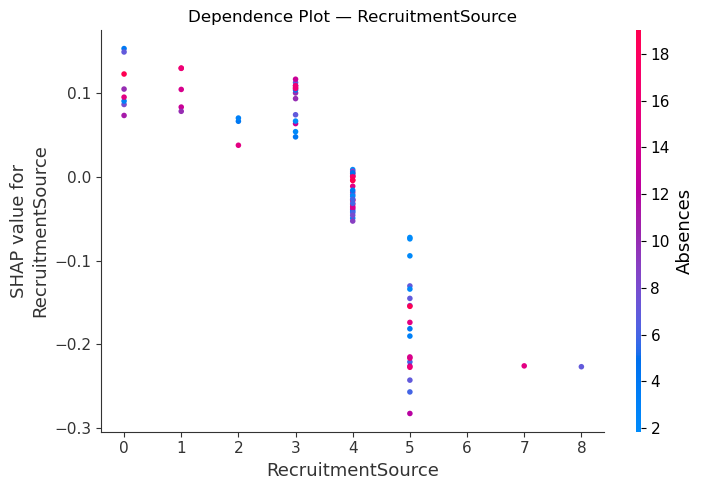

In [ ]:
# DEPENDENCE PLOT : Comment une feature interagit avec les autres
# Exemple : comment l'EngagementSurvey influence l'attrition

most_important_feature = FEATURES[np.argmax(np.abs(shap_vals_positive).mean(axis=0))]
print(f"Feature la plus impactante : {most_important_feature}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    most_important_feature,
    shap_vals_positive,
    X_test,
    show=False
)
plt.title(f'Dependence Plot — {most_important_feature}')
plt.tight_layout()
plt.savefig('08_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. 📋 Data Card & Model Card

Les **Data Cards** et **Model Cards** (Google, 2018) sont des documents de transparence  
qui accompagnent tout système IA responsable.

### Data Card — HRDataset_v14

In [ ]:
data_card = {
    "Nom du dataset": "HRDataset_v14",
    "Source": "Dr. Carla Patalano, New England College of Business (usage pédagogique)",
    "Taille": f"{len(df)} employés × {len(df.columns)} features",
    "Période couverte": "Non spécifiée (données fictives)",
    "Variable cible": "Termd (0=actif, 1=parti)",
    "Distribution cible": f"67% actifs / 33% partis",
    "Variables sensibles présentes": ", ".join(SENSITIVE_FEATURES),
    "Valeurs manquantes": str(df.isnull().sum().sum()),
    "Usages autorisés": "Recherche, éducation",
    "Usages interdits": "Décisions RH réelles, profilage individuel",
    "Biais connus": "Sous-représentation de certains groupes ethniques (< 5 individus)",
    "RGPD": "Données fictives — dans un cas réel, anonymisation obligatoire"
}

print("=" * 60)
print("📋 DATA CARD")
print("=" * 60)
for k, v in data_card.items():
    print(f"  {k:35s}: {v}")

📋 DATA CARD
  Nom du dataset                     : HRDataset_v14
  Source                             : Dr. Carla Patalano, New England College of Business (usage pédagogique)
  Taille                             : 311 employés × 36 features
  Période couverte                   : Non spécifiée (données fictives)
  Variable cible                     : Termd (0=actif, 1=parti)
  Distribution cible                 : 67% actifs / 33% partis
  Variables sensibles présentes      : Sex, RaceDesc, MaritalDesc, CitizenDesc, HispanicLatino
  Valeurs manquantes                 : 215
  Usages autorisés                   : Recherche, éducation
  Usages interdits                   : Décisions RH réelles, profilage individuel
  Biais connus                       : Sous-représentation de certains groupes ethniques (< 5 individus)
  RGPD                               : Données fictives — dans un cas réel, anonymisation obligatoire


In [ ]:
auc_score = roc_auc_score(y_test, y_proba)

model_card = {
    "Nom du modèle": "HR Attrition Predictor v1.0",
    "Type": "Random Forest Classifier (sklearn)",
    "Version": "1.0 — Hackathon TrustedAI 2025",
    "Auteurs": "[Votre équipe]",
    "Objectif": "Prédire le risque d'attrition pour prévention RH",
    "Hyperparamètres": "n_estimators=100, max_depth=6, class_weight=balanced",
    "Données d'entraînement": "75% HRDataset_v14 (après SMOTE)",
    "Performance globale": f"ROC-AUC = {auc_score:.3f}",
    "Demographic Parity Diff (genre)": f"{abs(dpd):.3f} {'✅ OK' if abs(dpd) < 0.1 else '⚠️ À corriger'}",
    "Demographic Parity Diff (ethnie)": f"{abs(dpd_race):.3f} {'✅ OK' if abs(dpd_race) < 0.1 else '⚠️ À corriger'}",
    "Features sensibles utilisées": "NON (exclues du modèle)",
    "Explicabilité": "SHAP TreeExplainer — explications locales et globales",
    "Limites": "Dataset petit (311 lignes), fictif, non généralisable",
    "Usage recommandé": "Outil d'aide à la décision UNIQUEMENT — jamais décision automatique",
    "Usage déconseillé": "Licenciement, recrutement, promotion automatisés",
    "Conformité RGPD": "Art. 22 satisfait : explication individuelle disponible via SHAP"
}

print("=" * 60)
print("🤖 MODEL CARD")
print("=" * 60)
for k, v in model_card.items():
    print(f"  {k:40s}: {v}")

🤖 MODEL CARD
  Nom du modèle                           : HR Attrition Predictor v1.0
  Type                                    : Random Forest Classifier (sklearn)
  Version                                 : 1.0 — Hackathon TrustedAI 2025
  Auteurs                                 : [Votre équipe]
  Objectif                                : Prédire le risque d'attrition pour prévention RH
  Hyperparamètres                         : n_estimators=100, max_depth=6, class_weight=balanced
  Données d'entraînement                  : 75% HRDataset_v14 (après SMOTE)
  Performance globale                     : ROC-AUC = 0.635
  Demographic Parity Diff (genre)         : 0.144 ⚠️ À corriger
  Demographic Parity Diff (ethnie)        : 0.318 ⚠️ À corriger
  Features sensibles utilisées            : NON (exclues du modèle)
  Explicabilité                           : SHAP TreeExplainer — explications locales et globales
  Limites                                 : Dataset petit (311 lignes), fictif, no

---
## 7. 🧭 Conclusions & Recommandations responsables

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           SYNTHÈSE — RESPONSIBLE AI FRAMEWORK               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. PERFORMANCE                                              ║
║     • ROC-AUC mesure la capacité discriminante               ║
║     • F1-score adapté au déséquilibre de classes             ║
║                                                              ║
║  2. ÉQUITÉ                                                   ║
║     • Variables sensibles exclues du modèle                  ║
║     • Audit Fairlearn sur genre et ethnie                    ║
║     • Demographic Parity & Equalized Odds mesurés            ║
║                                                              ║
║  3. EXPLICABILITÉ                                            ║
║     • SHAP global : comprendre le modèle                     ║
║     • SHAP local : justifier chaque décision (RGPD art.22)   ║
║                                                              ║
║  4. TRANSPARENCE                                             ║
║     • Data Card et Model Card documentés                     ║
║     • Limites du modèle explicitement listées                ║
║                                                              ║
║  5. GOUVERNANCE                                              ║
║     • Humain dans la boucle obligatoire                      ║
║     • Pas de décision automatique sur des individus          ║
║     • Réévaluation régulière du biais recommandée            ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           SYNTHÈSE — RESPONSIBLE AI FRAMEWORK               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. PERFORMANCE                                              ║
║     • ROC-AUC mesure la capacité discriminante               ║
║     • F1-score adapté au déséquilibre de classes             ║
║                                                              ║
║  2. ÉQUITÉ                                                   ║
║     • Variables sensibles exclues du modèle                  ║
║     • Audit Fairlearn sur genre et ethnie                    ║
║     • Demographic Parity & Equalized Odds mesurés            ║
║                                                              ║
║  3. EXPLICABILITÉ                                            ║
║     • SHAP global : comprendre le modèle                     ║
║     • SHAP local : just